<h2>Modeling Non-Linear Patterns with Activation Function</h2>
<br>
<ul>
    <li>when linear model can not fit curve then we use <b>Modeling Non-Linear Patterns with Activation Function</b> where we use to fit the curve and predict and to learn more complexity, curved pattern on real data</li>
    <li><b>ReLU Function </b> most popular and powerful function that use to buil sophisticated model and can fit many curves</li>
</ul>

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import helper_utils2
torch.manual_seed(42)

<h3>Prepare the Non-Linear Data</h3>

In [35]:
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

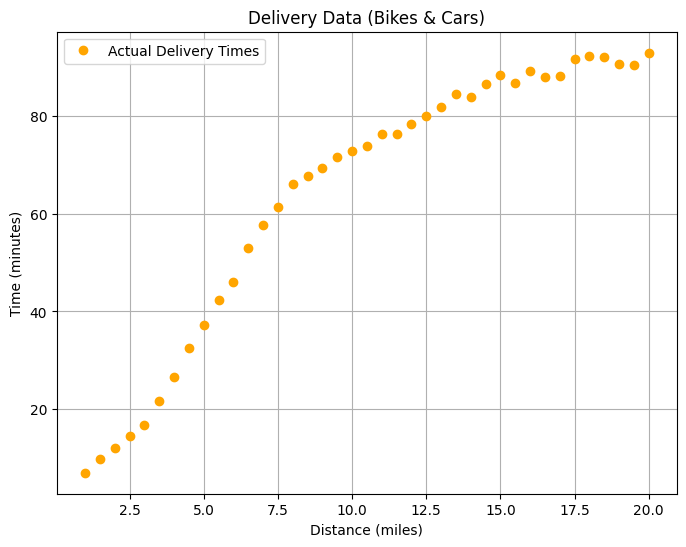

In [36]:
helper_utils2.plot_data(distances, times)

<h2>Normalizing the Data</h2>
Normalization - use for data preparation
<ul>
    <li>use to improve training process makes it more stable and effective </li>
    <li>prevent from dominating large scale feature to smaller one</li>
    <li>Helps to contribute each feature equally </li>
</ul>

<ol>
    <li>First find the mean and standard deviation for both distance and times </li>
    <li>apply standardization to each tensor using to mean and standard deviation that's create a new normalized <code>distance_norm times_norm</code></li>
    <li><b>standardization</b> or <i> z-score normalization</i> convert data into new form </li>
</ol>

In [39]:
distance_mean = distances.mean()
distance_std = distances.std()
#std mean how data is spread
times_mean = times.mean()
times_std = times.std()

#applying standardization to the distance
distances_norm = (distances - distance_mean) / distance_std
#(distances - distance_mean) = how far each value is from the mean
#Divide by distance_std = scales these differences so the result has
	#•	mean = 0
	#•	standard deviation = 1
#apply standardization to the times
times_norm = (times - times_mean) / times_std

#norm gives values that centered around 0 , all values are on same scale
#If distances = [10, 20, 30], mean = 20, std = 8.16, then
#distance_norm = [-1.22, 0, 1.22]
print(distances_norm.min(), distance_norm.max())
print(times_norm.min(), times_norm.max())

tensor(-1.6664) tensor(1.6664)
tensor(-2.0442) tensor(1.0347)


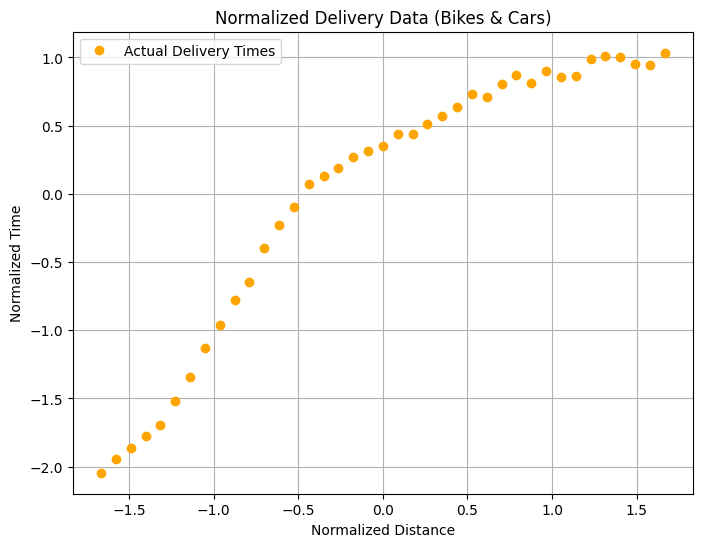

In [40]:
helper_utils2.plot_data(distances_norm, times_norm, normalize=True)

<h3>Building the Non-Linear Model</h3>
<br>
model's architecture thats is <code>ReLU</code> activation function which is uese to train complex model finding relationships in non-linear 


In [42]:
torch.manual_seed(27)

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3,1)
)


In [43]:
#training
#define the loss function and the optimizer for training 
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

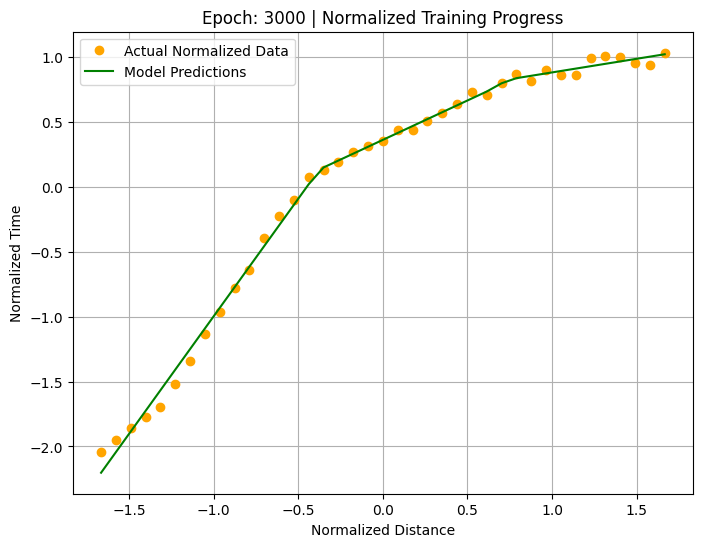


Training Complete

Final Loss: 0.0029681120067834854


In [47]:
#trainig loop
for epoch in range(3000):
    optimizer.zero_grad()#clear all previously stored gradient, models parameters
    #zero before the next backward pass
    output = model(distances_norm)
    loss = loss_function(output, times_norm)
    loss.backward()#calculation adjustment
    optimizer.step()#update models parameters

    #create a live plot for every 50 epochs
    if(epoch + 1) % 50 == 0:
        helper_utils2.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm
        )
print("\nTraining Complete")
print(f"\nFinal Loss: {loss.item()}")

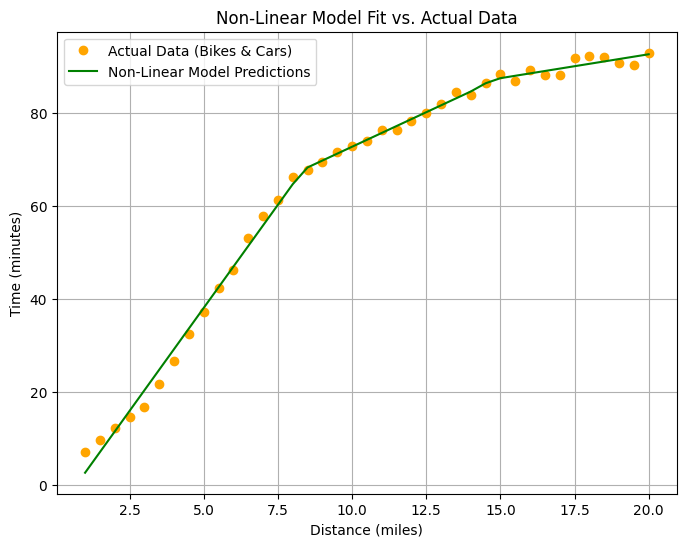

In [51]:
#checking final fit
helper_utils2.plot_final_fit(model, distances, times, distances_norm, times_std, times_mean)

In [57]:
#making some predictions 
distance_to_predict = 5.1


In [61]:
with torch.no_grad():
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distance_mean) / distance_std

#get the normalized prediction from the model
    predicted_time_norm = model(new_distance_norm)
     # De-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    
    # --- Decision Making Logic ---
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")
    
    # First, check if the delivery is possible within the 45-minute timeframe
    if predicted_time_actual.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

Prediction for a 5.1-mile delivery: 38.9 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.
